# Explore — live Postgres

Ad-hoc SQL against the pipeline database. Unlike `01_community_insight_brief.ipynb` (which reads the
exported Parquet snapshot), this talks to Postgres directly, so it always reflects the
**current** `normalize` / `profile` run.

`q("SELECT ...")` returns a DataFrame. `schema()` lists the tables.

In [17]:
import os
import pandas as pd
import psycopg

DSN = (f"postgresql://{os.getenv('POSTGRES_USER','mht')}:{os.getenv('POSTGRES_PASSWORD','mht')}"
       f"@{os.getenv('POSTGRES_HOST','postgres')}:{os.getenv('POSTGRES_PORT','5432')}"
       f"/{os.getenv('POSTGRES_DB','mht')}")

def q(sql, params=None):
    """Run SQL, return a DataFrame. Built straight on psycopg - no SQLAlchemy needed."""
    with psycopg.connect(DSN) as conn, conn.cursor() as cur:
        cur.execute(sql, params)
        if cur.description is None:
            return None
        cols = [c.name for c in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)

def schema():
    return q("""SELECT table_name, count(*) AS columns
                   FROM information_schema.columns
                  WHERE table_schema='public' GROUP BY 1 ORDER BY 1""")

# pd.set_option('display.max_colwidth', 90)
# pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', None)
schema()

,table_name,columns
0,demographic_claims,8
1,documents,10
2,extractions,11
3,jobs,8
4,mentions,24
5,switch_events,14
6,treatment_summary,12
7,user_profiles,25


In [66]:
# q(
# """
# -- SELECT MAX(LENGTH(body))
# SELECT AVG(LENGTH(body))
# FROM documents
# """
# )
# q(
# """
# SELECT MAX(LENGTH(context))
# FROM mentions
# """
# )
# q(
#     """
#     SELECT *
#     FROM demographic_claims
#     -- WHERE author_id = 'user_024'
#     WHERE author_id = 'user_001'
#     ORDER BY field
#     """
# )
# q(
#     """
#     SELECT *
#     FROM documents
#     -- WHERE doc_id = 'post_6a30a8c71028'
#     -- WHERE doc_id IN (
#     -- 'reply_138ccf2efdb8','reply_2428214b1bbc'
#     -- ,'reply_fd4de5d962c9','post_9d0475d302ef'
#     -- ,'reply_41d22f54be13','reply_16d7c0d539a6','reply_ef60e73d0b35'
#     -- )
#     -- WHERE doc_id IN ('reply_ec259409be2b', 'reply_9f826b676736') -- user_024 switch_events
#     WHERE doc_id IN (
#     'reply_e1fad71facce','post_b0ac96537a9d'
#     ,'reply_7a84758b14bf','post_2990f6e53787'
#     )
#     """
# )
# reply_138ccf2efdb8 == psycotherapist
# reply_2428214b1bbc | reply_fd4de5d962c9 | post_9d0475d302ef = age
# reply_41d22f54be13 |  reply_16d7c0d539a6 | reply_ef60e73d0b35 = location

# 0	demographic_claims	8
# 1	documents	10
# 2	extractions	11
# 3	jobs	8
# 4	mentions	24
# 5	switch_events	14
### 6	treatment_summary	12
## 7	user_profiles	25
# q(
# """
# SELECT *
# FROM switch_events
# WHERE author_id IN ('user_001', 'user_024','user_012')
# ORDER BY author_id, created_at
# """
# )
# q(
#     """
#     SELECT *
#     FROM mentions
#     WHERE supported is False
#     LIMIT 25
#     """
# )
q(
    """
    SELECT experienced_by,*
    FROM mentions
    where canonical_id like '%climara%'
    LIMIT 25
    """
)
# q(
#     """
# SELECT *
#                    FROM information_schema.columns
#                   WHERE table_schema='public' and table_name = 'mentions'
#     """
# )


,experienced_by,mention_id,doc_id,author_id,doc_type,created_at,kind,surface,canonical_id,canonical_class,...,sentiment,evidence,lexicon_hash,char_start,char_end,context,surface_found,context_source,supported,prompt_version
0,self,91,reply_f1ea8f7c3d0b,user_031,reply,2026-01-12 04:21:18.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,positive,I'm on the Climara patch now,74b9f4261eee,159.0,172.0,"…I'm not going to offer anything except — yes. This is grief and it's real and it deserves to be called what it is. I'm on the Climara patch now and it's helped the rage a bit but it hasn't fixed the feeling of being a stranger to myself, so I know that part isn't just…",True,surface,True,v7
1,general,112,reply_b3b0c2be9be8,user_056,reply,2026-03-01 04:52:38.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,neutral,headaches in the first 4-8 weeks are really common as your body adjusts to the new estrogen levels.,74b9f4261eee,404.0,409.0,"…they faded around weeks 6-10. That said, I had to stop HRT myself because of breast tenderness so I can't give you a personal patch success story — but from everything I've read, your gyno telling you to wait it out is actually pretty standard advice.",True,surface,False,v7
2,self,156,reply_5e9b860167c9,user_071,reply,2026-01-12 07:53:30.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,negative,the patch didn't work,74b9f4261eee,573.0,578.0,"…that even women who can't do systemic HRT can often use it, so theoretically it might still be an option for you even though the patch didn't work and I really think you should ask Midi specifically about this because they seem to actually know menopause vs a…",True,surface,False,v7
3,self,338,reply_1b22ae455e84,user_086,reply,2026-04-27 23:44:43.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,positive,"Urinary urgency actually improved slightly once the systemic oestrogen kicked in, which surprised me.",74b9f4261eee,73.0,86.0,"I made exactly this transition about two years ago — Vagifem plus added Climara patch, and then Prometrium. First month: breast tenderness yes, quite noticeable, lasted roughly six weeks for me. Bloating was a…",True,surface,True,v7
4,self,416,post_ce9db1d7cc43,user_001,post,2026-04-24 04:28:18.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,neutral,on estrogen (Climara patch),74b9f4261eee,569.0,582.0,…I've heard of ocular migraines and that's what it sounds like but I have never had migraines in my life. I'm 51 and on estrogen (Climara patch). I did call my doctor and she didn't seem overly alarmed and said to come in if it happened again. I also of course went…,True,surface,True,v7
5,general,498,reply_d6b222248adc,user_056,reply,2025-11-24 11:15:11.910996+00:00,treatment,Climara,climara,transdermal_estradiol,...,neutral,recommended for hormone-related headaches,74b9f4261eee,191.0,198.0,"…hormone-related headaches — I've seen this come up SO many times on r/menopause and in the peri Facebook groups. Estradot and Climara are both estradiol patches, Estradot just changes every 3-4 days vs Climara's weekly change, so some people prefer the more…",True,surface,True,v7
6,self,522,reply_4fcdc77f6200,user_070,reply,2026-05-02 03:57:07.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,mixed,reading this makes me nervous because I'm considering starting HRT soon,74b9f4261eee,10.0,81.0,"Oh gosh, reading this makes me nervous because I'm considering starting HRT soon and now I'm wondering — does the breast tenderness happen to everyone at 0.05? Is it definitely the estradiol and not the…",False,evidence,False,v7
7,self,554,post_0a0f31aac2f2,user_091,post,2026-04-08 05:43:16.910996+00:00,treatment,Climara patch,climara,transdermal_estradiol,...,negative,been on the Climara patch for almost 8 months now,74b9f4261eee,90.0,103.0,temple hair loss getting worse even on the patch — anyone else?? okay so i've been on the Cli

## Which extraction run is loaded?

`mentions` is rebuilt by `normalize` from a single `prompt_version`. Everything below
describes whichever run that was — check it before trusting a number.

In [47]:
q("""SELECT prompt_version, model, count(*) AS extractions,
              count(*) FILTER (WHERE parsed_ok) AS parsed_ok
         FROM extractions GROUP BY 1,2 ORDER BY 1""")

,prompt_version,model,extractions,parsed_ok
0,v1,llama3.1:8b,10,10
1,v2,llama3.1:8b,12,12
2,v3,llama3.1:8b,12,12
3,v4,llama3.1:8b,341,340
4,v5,llama3.1:8b,9991,9991
5,v6-noparent,llama3.1:8b,300,300
6,v7,llama3.1:8b,9991,9991


## The four grains

Documents fan out into mentions, then fan back in per author. `parent_id` links a reply to
its post but is **never** grouped on — all aggregation is by `(author_id, canonical_id)`.

In [60]:
q("""SELECT 'documents' AS grain, count(*)::int AS rows FROM documents
 UNION ALL SELECT 'mentions (supported)', count(*) FROM mentions WHERE supported
 UNION ALL SELECT 'mentions (supported, non-null context)', count(*) FROM mentions WHERE context IS NOT NULL AND supported
 UNION ALL SELECT 'switch_events',        count(*) FROM switch_events
 -- UNION ALL SELECT 'switch_events (supported)',        count(*) FROM switch_events WHERE doc_id IN (SELECT DISTINCT doc_id FROM mentions WHERE supported)
 UNION ALL SELECT 'user_profiles',        count(*) FROM user_profiles
 UNION ALL SELECT 'treatment_summary',    count(*) FROM treatment_summary""")

,grain,rows
0,documents,9991
1,mentions (supported),36194
2,"mentions (supported, non-null context)",35750
3,switch_events,405
4,user_profiles,100
5,treatment_summary,76


## Cohort sizing — why a threshold, not "any mention"

"Any self-attributed mention" counts everyone who ever *discussed* the drug. The
distribution is bimodal: a long tail of members who mentioned it once or twice while
answering someone else, and a small group who mention it constantly because they take it.
Read the gap off this table before picking a cut.

In [5]:
import numpy as np

CANON = 'climara'   # <- change to profile any other entity

counts = q("""SELECT author_id, count(*) AS n FROM mentions
               WHERE canonical_id = %s AND kind = 'treatment'
                 AND experienced_by = 'self' AND supported
               GROUP BY author_id ORDER BY n DESC""", (CANON,))

def derive_cut(v):
    """Largest gap and Otsu, independently. Same derivation as notebook 01 - a
    hardcoded threshold here would drift from the brief the moment either moved."""
    v = np.sort(np.asarray(v, dtype=float))[::-1]
    if len(v) < 4:
        return None, None
    i = int(np.argmax(v[:-1] - v[1:]))
    gap = (v[i] + v[i + 1]) / 2
    best, otsu = -1.0, v.min()
    for t in np.unique(v):
        hi, lo = v[v >= t], v[v < t]
        if len(hi) and len(lo):
            w = len(hi) * len(lo) * (hi.mean() - lo.mean()) ** 2
            if w > best:
                best, otsu = w, t
    return gap, otsu

gap, otsu = derive_cut(counts.n)
by_gap  = set(counts[counts.n >= gap].author_id)  if gap  is not None else set()
by_otsu = set(counts[counts.n >= otsu].author_id) if otsu is not None else set()
agree = bool(by_gap) and by_gap == by_otsu

dist = (counts.n.value_counts().sort_index()
        .rename_axis('mentions_by_member').reset_index(name='members'))
display(dist)
print(f"any mention : {len(counts)} members")
print(f"largest gap : >= {gap}   -> {len(by_gap)} members")
print(f"Otsu        : >= {otsu}  -> {len(by_otsu)} members")
print("methods " + ("AGREE - cohort is real" if agree else "DISAGREE - no distinct cohort"))
COHORT = by_gap if agree else set()

,mentions_by_member,members
0,1,22
1,2,17
2,3,7
3,4,8
4,5,2
5,6,1
6,7,1
7,8,1
8,49,3
9,54,1


any mention : 66 members
largest gap : >= 28.5   -> 7 members
Otsu        : >= 49.0  -> 7 members
methods AGREE - cohort is real


## Who is in the cohort

In [6]:
q("""WITH cohort AS (
        SELECT author_id FROM mentions
         WHERE canonical_id=%s AND kind='treatment' AND experienced_by='self' AND supported
         GROUP BY author_id HAVING count(*) >= 2)
      SELECT p.author_id, p.age, p.country, p.profession, p.prescriber_type, p.n_docs
        FROM user_profiles p JOIN cohort c USING (author_id)
       ORDER BY p.age NULLS LAST""", (CANON,))

,author_id,age,country,profession,prescriber_type,n_docs
0,user_034,38,NaN,consultant,specialist,103
1,user_080,39,Ireland,neurologist,telehealth,95
2,user_030,39,the States,teacher,specialist,92
3,user_026,39,Ireland,logistics operation,NaN,106
4,user_052,40,NaN,management consulting,telehealth,105
5,user_087,40,NaN,litigator,telehealth,101
6,user_090,41,NaN,neurologist,specialist,110
7,user_018,42,USA,accountant,telehealth,97
8,user_007,43,NaN,software engineer,NaN,101
9,user_071,43,NaN,marketing director,specialist,98


## Switching — direction matters

In [74]:
q("""SELECT coalesce(from_canonical, '['||from_surface||']') AS from_,
              coalesce(to_canonical,   '['||to_surface||']')   AS to_,
              count(*) AS n
         FROM switch_events
        WHERE from_canonical=%s OR to_canonical=%s
        GROUP BY 1,2 ORDER BY n DESC LIMIT 20""", (CANON, CANON))

,from_,to_,n
0,climara,estradot,13
1,climara,[unspecified],9
2,oral_estradiol,climara,8
3,climara,estradiol_gel_generic,7
4,estradot,climara,4
5,compounded_bhrt,climara,4
6,activelle,climara,4
7,climara,oral_estradiol,3
8,climara,climara,3
9,climara,patch_unspecified,3


### Product handling complaints (adhesion)

There is no `tolerability` column. It was tried as an extraction field and removed:
only ~47% of what the model emitted was grounded in the source text, and its
commonest label fired on drug side effects rather than product handling.

The signal is still here, in two better places — adhesion-driven **switches** in
`switch_events.reason`, and the raw language in the documents themselves.

In [8]:
# 1. switches caused by adhesion - already part of the data product
display(q("""SELECT from_canonical, to_canonical, reason, left(evidence, 70) AS evidence
              FROM switch_events
             WHERE reason ~* 'adhes|stick|peel|fall'
             ORDER BY from_canonical LIMIT 10"""))

# 2. documents carrying adhesion language. 'adhesive capsulitis' is frozen
#    shoulder, a symptom - exclude it or it doubles the count (40 of 120 naive
#    matches in this corpus).
display(q("""SELECT count(*) AS docs_with_adhesion_language FROM documents
              WHERE body ~* 'adhes' AND body !~* 'adhesive capsulitis'"""))

display(q("""SELECT d.doc_id, d.author_id,
                    substring(regexp_replace(d.body, E'\n', ' ', 'g')
                              from greatest(1, position('adhes' in lower(d.body)) - 70)
                              for 150) AS quote
               FROM documents d
              WHERE d.body ~* 'adhes' AND d.body !~* 'adhesive capsulitis'
              LIMIT 12"""))

,from_canonical,to_canonical,reason,evidence
0,activelle,estradiol_patch_generic,adhesion issues,my gyno mentioned at my last appointment that we could consider switch
1,activelle,patch_unspecified,adhesion issues,I switched to a patch six months ago
2,climara,estradot,adhesive issues,My derm thinks the Climara adhesive might be causing my hive situation
3,climara,estradiol_gel_generic,adhesive issues,My derm thinks the Climara adhesive might be causing my hive situation
4,climara,estradot,adhesive issues,the adhesive is different and maybe the hormone delivery is more consi
5,climara,estradot,adhesive issues,The adhesive is noticeably more aggressive — I had skin irritation at
6,climara,estradiol_gel_generic,adhesion issues,women in my life who switched
7,climara,estradot,adhesion issues,switched from a similar matrix patch
8,climara,estradiol_gel_generic,adhesion issues,patch edges peel in this NC humidity
9,climara,divigel,adhesion issues,my prescriber mentioned possibly switching to a gel for more consisten


,docs_with_adhesion_language
0,67


,doc_id,author_id,quote
0,post_04f38fd0244d,user_005,"out 8 months. The hives started maybe 6 weeks ago. Could be the patch adhesive, could ..."
1,post_a61187f8f40b,user_005,My derm thinks the Climara adhesive might be causing my hive situation. So now I'm loo...
2,post_ff25887c5b09,user_005,adot and it works fine. Climara is bigger which is annoying. Does the adhesive differ?...
3,post_a10c2113c504,user_007,"e on the T side, so I know transdermal CAN work for me. But the patch adhesion is driv..."
4,post_0f35fdebb480,user_010,ggested gel might give me slightly better dose flexibility. The patch adhesion is also...
5,post_5e3365aae9e5,user_013,son I like the gel is I don't have to think about patch placement and adhesion issues ...
6,post_110367a81488,user_018,"h honestly is practical - I'm in Austin, it is HOT, and in summer the adhesive just do..."
7,post_0a59d93346cc,user_022,et so I'm pretty clinical about this stuff — it's basically just a bioadhesive polymer...
8,post_74456db4ce1b,user_024,st freshly painted canvases and ruining both the canvas AND the patch adhesive situati...
9,post_d7a63eb5061f,user_033,s I'm trying to understand from people's actual experience: Does the adhesion differe...


## Receipts

Every row traces back to the member's own words. `context` is located deterministically in
the source text — `context_source` says how it was found.

In [9]:
q("""SELECT author_id, stance, experienced_by, context_source, context
         FROM mentions
        WHERE canonical_id=%s AND kind='treatment' AND experienced_by='self'
          AND supported AND context IS NOT NULL
        ORDER BY random() LIMIT 8""", (CANON,))

,author_id,stance,experienced_by,context_source,context
0,user_091,current,self,surface,Yes yes yes to acupuncture!! 🫂 I did a whole course of it before I started my Climara ...
1,user_079,past,self,surface,…I can barely talk about it even here but it's really affecting my relationship and I ...
2,user_082,current,self,surface,…surfacing things that get buried in the busyness of the day — your heart literally de...
3,user_001,current,self,surface,"…it's not about being told what to do, it's about having better information going into..."
4,user_078,past,self,surface,"…now, I'm on Divigel which is helping with the brain fog somewhat but the mood stuff i..."
5,user_026,current,self,surface,"…do think it takes the edge off the mood swings, hard to say how much is placebo but a..."
6,user_001,current,self,surface,"…breast cancer thing, my mom had it and I had a whole conversation with my doctor abou..."
7,user_085,current,self,surface,"…doesn't really GET it the way it sounds like your person does, and the dry skin oh go..."


## Data-quality counters

`supported=false` marks a branded product the document text does not actually contain —
kept for audit, excluded from every aggregate.

In [10]:
q("""SELECT
        count(*) AS mentions,
        count(*) FILTER (WHERE NOT supported)            AS unsupported_brand,
        count(*) FILTER (WHERE canonical_id IS NULL)     AS out_of_vocabulary,
        count(*) FILTER (WHERE context IS NULL)          AS no_context,
        round(100.0*count(*) FILTER (WHERE canonical_id IS NOT NULL)/count(*),1) AS pct_mapped
      FROM mentions""")

,mentions,unsupported_brand,out_of_vocabulary,no_context,pct_mapped
0,36554,360,4189,559,88.5


## Lexicon backlog

Surfaces that mapped to nothing. The highest-count rows are the next aliases worth adding
to `config/lexicon.yml`; re-running `make normalize` afterwards costs no model calls.

In [11]:
q("""SELECT kind, lower(surface) AS surface, count(*) AS n
         FROM mentions WHERE canonical_id IS NULL
        GROUP BY 1,2 ORDER BY n DESC LIMIT 25""")

,kind,surface,n
0,treatment,drug-a,82
1,treatment,menopause,62
2,treatment,supplements,20
3,symptom,menopause,20
4,treatment,peri,18
5,treatment,pills,17
6,treatment,maple,15
7,treatment,fermented foods,13
8,treatment,endocrinologist,12
9,treatment,allergist,12


---
# Member profiles

> **These numbers will not match `01_climara_brief.ipynb`, and that is expected.**
> This notebook reads **live Postgres**; `01` reads the exported **Parquet
> snapshot**. They are the same extraction run, but the live tables have been
> rebuilt with newer normalize code — 1,167 mentions are currently flagged
> unsupported here versus 94 in the snapshot, because the name-attestation check no
> longer accepts a parent post as evidence. Once the current run finishes and
> `make normalize profile export` is re-run, the two agree again.

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Colour by job. Categorical = identity (fixed order, never cycled), sequential =
# magnitude, diverging = polarity with a NEUTRAL midpoint. Validated palette:
# worst adjacent CVD dE 24.7, normal-vision 33.6.
C1, C2 = '#2a78d6', '#eb6834'
INK, INK2, MUTED, SURFACE = '#0b0b0b', '#52514e', '#8a8984', '#fcfcfb'
DIV_NEG, DIV_MID, DIV_POS = '#e34948', '#f0efec', '#2a78d6'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#eef4fd', '#9ec5f4', '#3987e5', '#184f95'])
DIV = LinearSegmentedColormap.from_list('div_br', [DIV_NEG, DIV_MID, DIV_POS])

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': INK2,
    'text.color': INK, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': True, 'grid.color': '#e8e7e2', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 120,
})

def tidy(ax, title, sub=None):
    ax.set_title(title, color=INK, fontsize=11.5, pad=24 if sub else 8, loc='left')
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=9, va='bottom')
    ax.set_axisbelow(True)
    return ax

prof = q("SELECT * FROM user_profiles")

# `country` is extracted from free text and is NOT clean: US states and phrases
# like "not in the US" land in it. Fold what is unambiguous, drop what is not,
# and report the coverage rather than implying the column is tidy.
US_STATES = {
    'alabama','alaska','arizona','arkansas','california','colorado','connecticut',
    'delaware','florida','georgia','hawaii','idaho','illinois','indiana','iowa',
    'kansas','kentucky','louisiana','maine','maryland','massachusetts','michigan',
    'minnesota','mississippi','missouri','montana','nebraska','nevada','new hampshire',
    'new jersey','new mexico','new york','north carolina','north dakota','ohio',
    'oklahoma','oregon','pennsylvania','rhode island','south carolina','south dakota',
    'tennessee','texas','utah','vermont','virginia','washington','west virginia',
    'wisconsin','wyoming',
}

def clean_country(v):
    # NOTE: float('nan') is TRUTHY - `if not v` does not catch it, and an
    # unguarded str(nan) becomes the literal 'nan', which showed up as a
    # 37-member country bucket.
    if v is None or (isinstance(v, float) and pd.isna(v)) or str(v).strip() == '':
        return None
    s = str(v).strip().lower()
    if s in US_STATES or s in {'usa','u.s.','united states','us'}: return 'US'
    if s.startswith('not in'): return None
    return {'uk':'UK','england':'UK','scotland':'UK','wales':'UK',
            'canada':'Canada','australia':'Australia','ireland':'Ireland',
            'new zealand':'New Zealand'}.get(s, str(v).strip())
prof['country_clean'] = prof.country.map(clean_country)

# has_partner is True for all 100 members: the extraction records a partner
# when one is mentioned and never records absence, so the field carries no
# information and is excluded from every breakdown below.
print("has_partner values:", prof.has_partner.value_counts(dropna=False).to_dict())
print(f"profiles {len(prof)}  ·  age {prof.age.notna().sum()}  ·  profession {prof.profession.notna().sum()}"
      f"  ·  prescriber {prof.prescriber_type.notna().sum()}  ·  country {prof.country_clean.notna().sum()}")

has_partner values: {True: 94, False: 6}
profiles 100  ·  age 100  ·  profession 99  ·  prescriber 83  ·  country 35


### Who is in the community

Four distributions, each a single series, so no legend is needed — the title names
the measure. Counts sit on the bars because with n=100 the reader wants the number,
not an estimate off an axis.

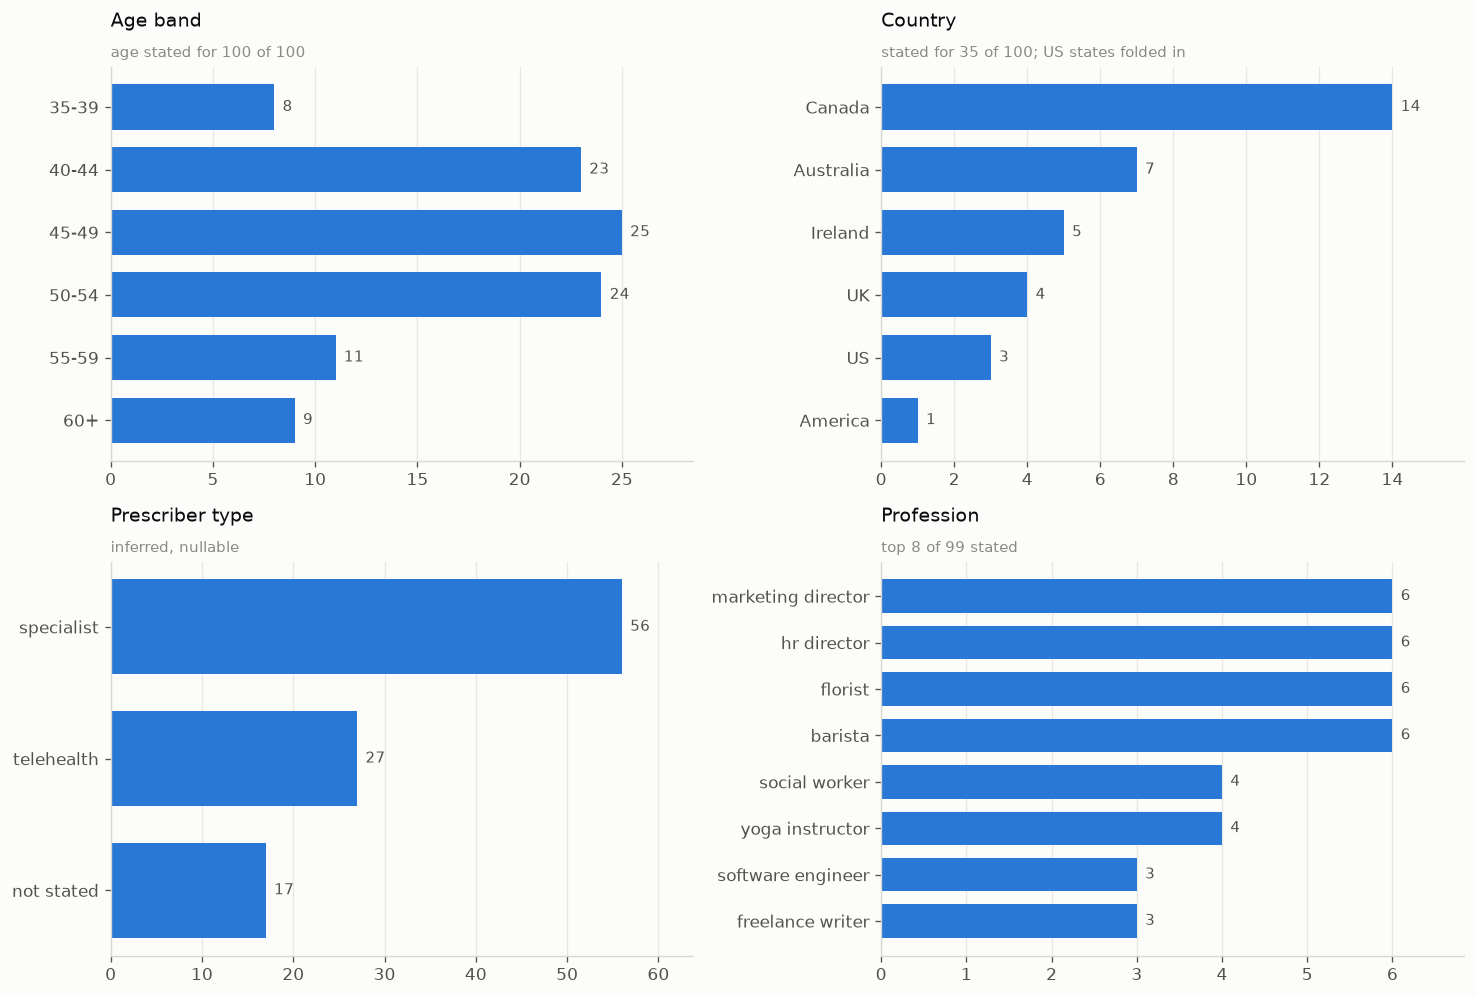

In [13]:
import numpy as np

bands = pd.cut(prof.age, [34, 39, 44, 49, 54, 59, 70],
               labels=['35-39','40-44','45-49','50-54','55-59','60+'])

panels = [
    ('Age band',        bands.value_counts().sort_index(),                       'age stated for %d of %d' % (prof.age.notna().sum(), len(prof))),
    ('Country',         prof.country_clean.value_counts().head(6),               'stated for %d of %d; US states folded in' % (prof.country_clean.notna().sum(), len(prof))),
    ('Prescriber type', prof.prescriber_type.fillna('not stated').value_counts(),'inferred, nullable'),
    ('Profession',      prof.profession.dropna().str.lower().value_counts().head(8), 'top 8 of %d stated' % prof.profession.notna().sum()),
]

fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.4))
for ax, (title, s, sub) in zip(axes.ravel(), panels):
    ax.barh(range(len(s))[::-1], s.values, color=C1, height=0.72)
    ax.set_yticks(range(len(s))[::-1])
    ax.set_yticklabels([str(i)[:28] for i in s.index])
    ax.grid(axis='y', visible=False)
    ax.margins(x=0.14)
    for i, v in zip(range(len(s))[::-1], s.values):
        ax.annotate(str(v), xy=(v, i), xytext=(5, 0), textcoords='offset points',
                    va='center', color=INK2, fontsize=9)
    tidy(ax, title, sub)
plt.tight_layout(); plt.show()

### Who likes Climara, and who doesn't

**Rebuilt — the first version's arithmetic was wrong in two ways.**

It averaged a *per-member* score, so a member with **one** mention scored ±1.0 on no
evidence and carried the same weight as a member with 65 mentions. The median member
has only **2** Climara sentiment mentions, so those singletons dominated every
bucket. It also ranked buckets from *different dimensions* in one sorted list, which
invites reading "UK" against "telehealth" as if they were alternatives — they are
overlapping slices of the same 100 people.

Now: sentiment is **pooled within the bucket** — `(positive − negative) / all
mentions` — so a bucket's number is weighted by the evidence behind it. Each
dimension gets **its own chart**, and buckets must clear **both** a mention floor and a
member floor — a mention floor alone admitted a one-person "country rate".

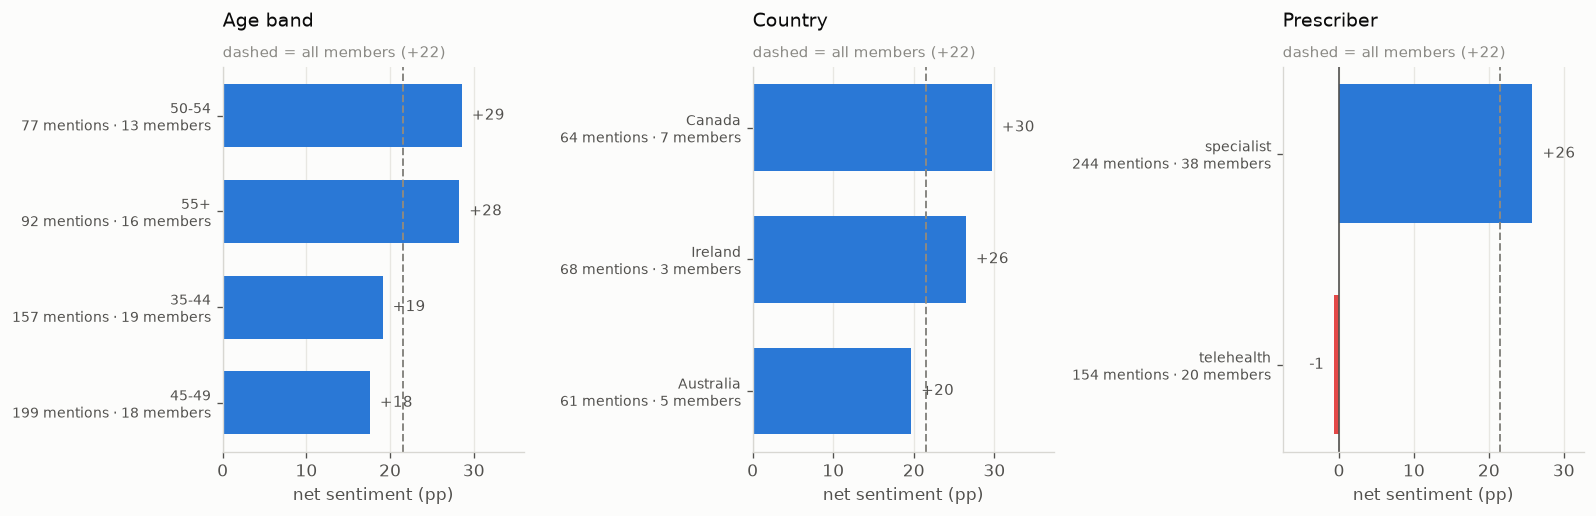

525 Climara sentiment mentions from 66 members · overall net +21.5pp · buckets need >=20 mentions AND >=3 members


In [14]:
# A rate needs BOTH enough mentions and enough independent people. A mention
# floor alone let "Ireland: 62 mentions, 1 member" through - one person's opinion
# drawn as a country rate.
MIN_MENTIONS = 20
MIN_MEMBERS  = 3

cl = q("""SELECT m.author_id, m.sentiment
            FROM mentions m
           WHERE m.canonical_id = 'climara' AND m.kind = 'treatment'
             AND m.experienced_by = 'self' AND m.supported
             AND m.sentiment IS NOT NULL""")

d = cl.merge(prof, on='author_id', how='left')
d['age_band'] = pd.cut(d.age, [34, 44, 49, 54, 70], labels=['35-44', '45-49', '50-54', '55+'])

def pooled(df):
    """Net sentiment over ALL mentions in the group - evidence-weighted, so a
    member with 60 mentions counts 60 times and one with a single mention counts
    once. Neutral and mixed stay in the denominator: they are real mentions that
    are simply not polarised."""
    n = len(df)
    return pd.Series({'net': (df.sentiment.eq('positive').sum()
                              - df.sentiment.eq('negative').sum()) / n,
                      'mentions': n, 'members': df.author_id.nunique()})

DIMS = [('age_band', 'Age band'), ('country_clean', 'Country'), ('prescriber_type', 'Prescriber')]
overall = (d.sentiment.eq('positive').sum() - d.sentiment.eq('negative').sum()) / len(d)

fig, axes = plt.subplots(1, len(DIMS), figsize=(13.4, 4.4))
for ax, (dim, label) in zip(axes, DIMS):
    g = (d.dropna(subset=[dim]).groupby(dim, observed=True)
           .apply(pooled, include_groups=False)
           .query('mentions >= @MIN_MENTIONS and members >= @MIN_MEMBERS')
           .sort_values('net'))
    if g.empty:
        ax.axis('off'); tidy(ax, label, 'no bucket clears both floors'); continue
    vals = g.net.values * 100
    ax.barh(range(len(g)), vals,
            color=[DIV_POS if v > 0 else DIV_NEG for v in vals], height=0.66)
    ax.axvline(0, color=INK2, lw=1)
    ax.axvline(overall * 100, color=MUTED, lw=1.2, ls='--')
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f'{i}\n{int(r.mentions)} mentions · {int(r.members)} members'
                        for i, r in g.iterrows()], fontsize=8.5)
    ax.set_xlabel('net sentiment (pp)')
    ax.grid(axis='y', visible=False); ax.margins(x=0.26)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:+.0f}', xy=(v, i), xytext=(6 if v > 0 else -6, 0),
                    textcoords='offset points', va='center',
                    ha='left' if v > 0 else 'right', color=INK2, fontsize=9)
    tidy(ax, label, f'dashed = all members ({overall*100:+.0f})')
plt.tight_layout(); plt.show()

print(f'{len(d)} Climara sentiment mentions from {d.author_id.nunique()} members · '
      f'overall net {overall*100:+.1f}pp · buckets need >={MIN_MENTIONS} mentions AND >={MIN_MEMBERS} members')

### What each group actually uses

**Rebuilt — the first version saturated and ignored stance.**

It asked "what fraction of this bucket ever self-mentioned treatment X", and the
common treatments are mentioned by **69–100 of 100 members**, so every cell landed in
the 70–100% band and no group could be told from another. It also counted a member
who *rejected* a product the same as one currently on it — 450 `current` versus 5
`rejected` mentions of Climara, all weighted alike.

Now: **share of a member's own treatment mentions**, restricted to stances that mean
actual use (`current`, `past`), averaged within the bucket. Continuous rather than
binary, so it does not saturate — the same fix that repaired the symptom chart.

umbrella entities excluded from the display: dose_change, estradiol_gel_generic, estradiol_patch_generic, hrt_unspecified, patch_unspecified, systemic_estrogen_unspecified, vaginal_estrogen_unspecified


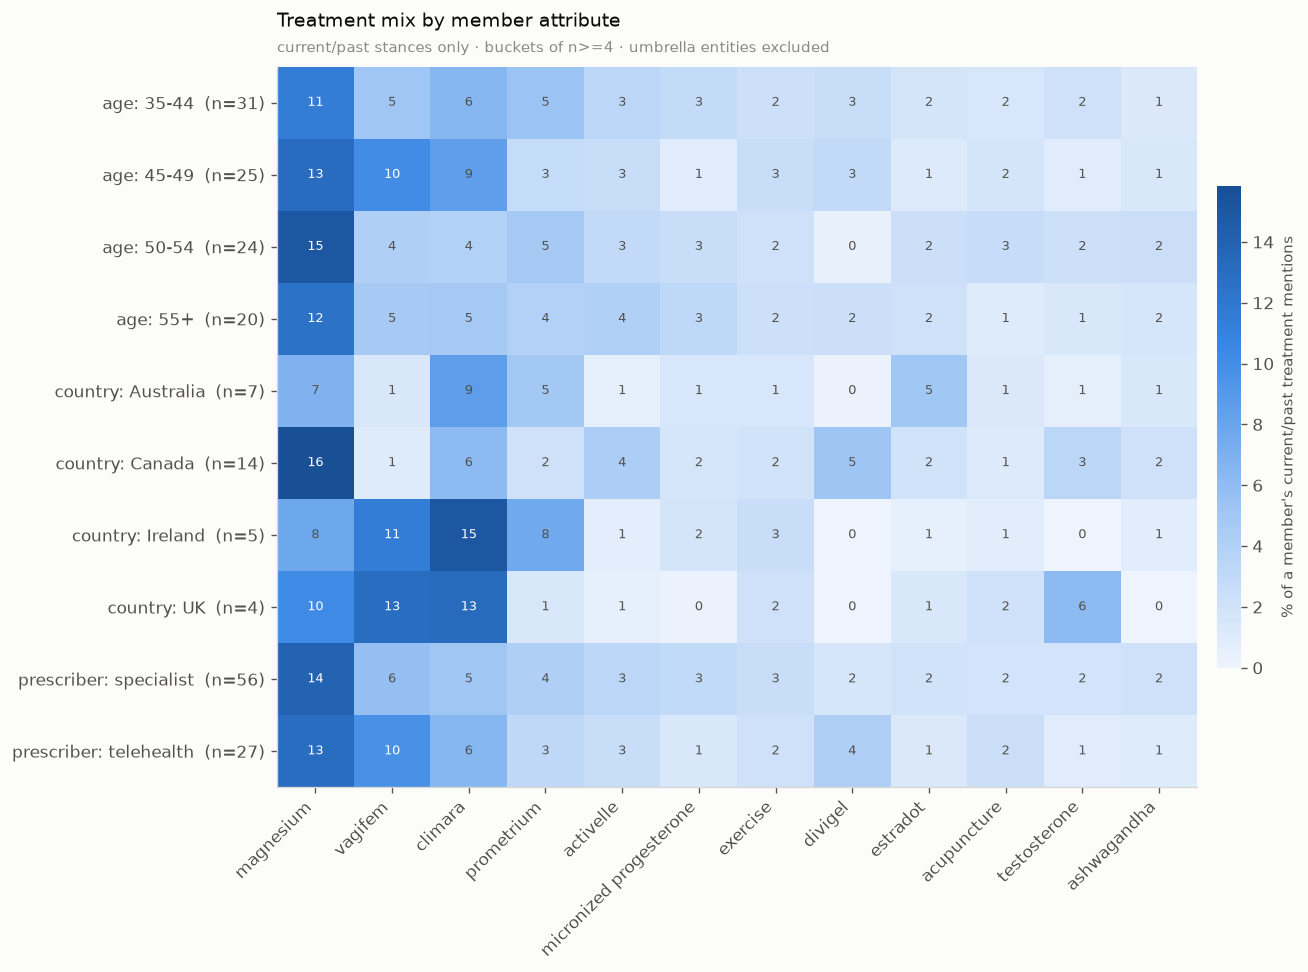

share of each bucket's mix covered by the 12 charted NAMED treatments,
and by the umbrella entities that are not charted:
                                charted %  umbrella %
age: 35-44  (n=31)                     46          42
age: 45-49  (n=25)                     48          38
age: 50-54  (n=24)                     45          43
age: 55+  (n=20)                       44          44
country: Australia  (n=7)              34          58
country: Canada  (n=14)                47          37
country: Ireland  (n=5)                49          44
country: UK  (n=4)                     50          38
prescriber: specialist  (n=56)         47          40
prescriber: telehealth  (n=27)         48          41


In [15]:
use = q("""SELECT author_id, canonical_id
             FROM mentions
            WHERE kind = 'treatment' AND experienced_by = 'self' AND supported
              AND stance IN ('current', 'past')
              AND canonical_id IS NOT NULL AND canonical_id <> 'non_entity'""")

per = use.groupby(['author_id', 'canonical_id']).size().unstack(fill_value=0)
mix = per.div(per.sum(axis=1), axis=0)           # each member's treatment mix

# Umbrella entities are "the member did not name a product" buckets. Left in,
# hrt_unspecified alone takes 19-38% of every row, compressing the colour scale so
# the named products all look flat - and "some kind of HRT" is not an actionable
# row for anyone. The mix is still computed over everything; only the DISPLAY drops
# them, so the printed row sums show how much each bucket they accounted for.
UMBRELLA = [c for c in mix.columns
            if c.endswith(('_unspecified', '_generic')) or c == 'dose_change']
named = [c for c in mix.columns if c not in UMBRELLA]
print(f'umbrella entities excluded from the display: {", ".join(sorted(UMBRELLA))}')
top_tx = mix[named].mean().sort_values(ascending=False).head(12).index

d2 = prof.set_index('author_id')
d2['age_band'] = pd.cut(d2.age, [34, 44, 49, 54, 70], labels=['35-44', '45-49', '50-54', '55+'])

rows, group_members = {}, {}
for dim, label in [('age_band', 'age'), ('country_clean', 'country'), ('prescriber_type', 'prescriber')]:
    for k, idx in d2.dropna(subset=[dim]).groupby(dim, observed=True).groups.items():
        members = mix.index.intersection(idx)
        if len(members) >= 4:
            key = f'{label}: {k}  (n={len(members)})'
            rows[key] = mix.loc[members, top_tx].mean()
            group_members[key] = members

mat = pd.DataFrame(rows).T
mat.columns = [c.replace('_', ' ') for c in mat.columns]

fig, ax = plt.subplots(figsize=(11, 0.46 * len(mat) + 3.6))
im = ax.imshow(mat.values * 100, cmap=SEQ, aspect='auto', vmin=0)
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
ax.grid(False)
hi = mat.values.max() * 100
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j] * 100
        ax.annotate(f'{v:.0f}', (j, i), ha='center', va='center', fontsize=7.5,
                    color='white' if v > hi * 0.6 else INK2)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("% of a member's current/past treatment mentions", color=INK2, fontsize=9)
cb.outline.set_visible(False)
tidy(ax, 'Treatment mix by member attribute',
     'current/past stances only · buckets of n>=4 · umbrella entities excluded')
plt.tight_layout(); plt.show()

print('share of each bucket\'s mix covered by the 12 charted NAMED treatments,')
print('and by the umbrella entities that are not charted:')
cover = pd.DataFrame({
    'charted %': (mat.sum(axis=1) * 100).round(0).astype(int),
    'umbrella %': pd.Series({g: round(mix.loc[mix.index.intersection(idx), UMBRELLA].mean().sum() * 100)
                             for g, idx in group_members.items()}).astype(int),
})
print(cover.to_string())

---
# Symptoms

The notebook was entirely treatment-side until here. These cells add the symptom
grain, then use it to ask what actually accompanies a switch.

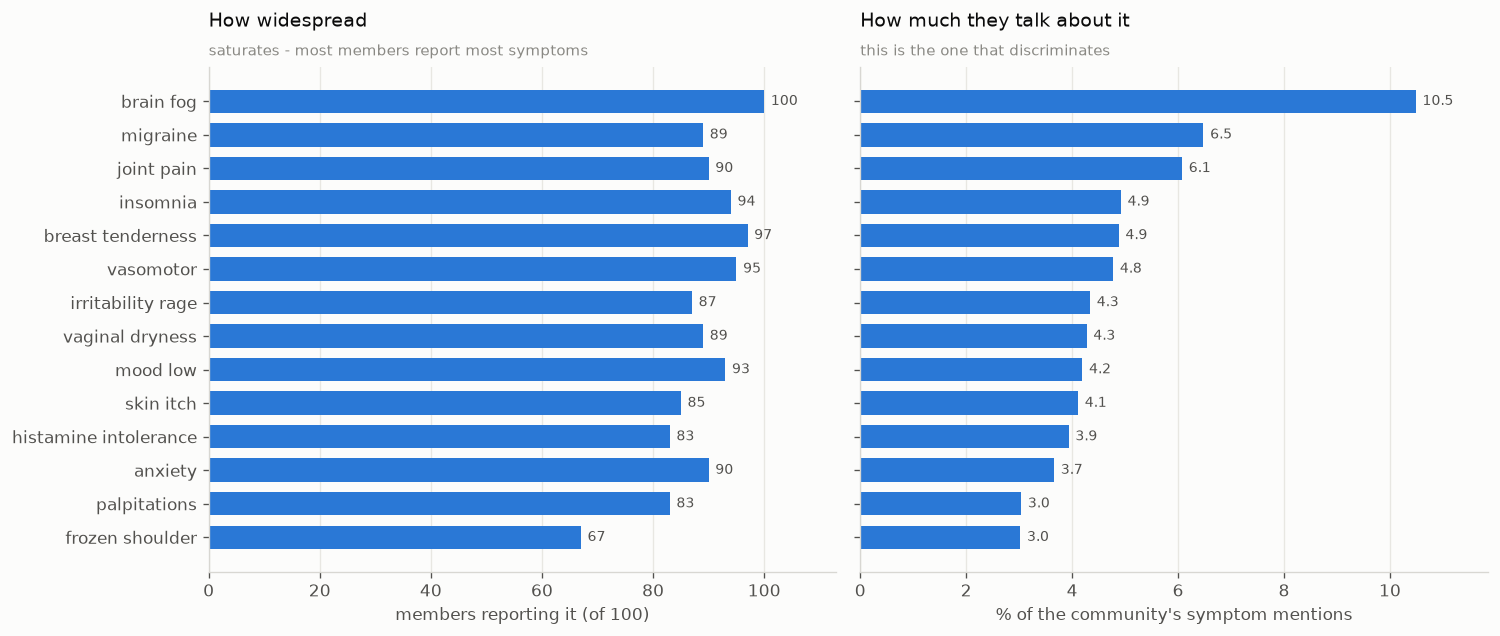

12,377 self-reported symptom mentions · 33 distinct symptoms


In [16]:
sym = q("""SELECT author_id, doc_id, canonical_id, status, created_at
             FROM mentions
            WHERE kind = 'symptom' AND experienced_by = 'self' AND supported
              AND canonical_id IS NOT NULL""")

# Two views, because they answer different questions and one saturates.
#   members      - how widespread is it (saturates: nearly everyone reports
#                  nearly everything across ~100 documents each)
#   mention share- how much of the community's symptom talk it takes up
members = sym.groupby('canonical_id').author_id.nunique().sort_values(ascending=False)
share   = sym.canonical_id.value_counts(normalize=True)

top = share.head(14).index[::-1]
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.4), sharey=True)

ax = axes[0]
ax.barh(range(len(top)), [members[t] for t in top], color=C1, height=0.7)
ax.set_yticks(range(len(top))); ax.set_yticklabels([t.replace('_',' ') for t in top])
ax.set_xlabel('members reporting it (of 100)')
ax.grid(axis='y', visible=False); ax.margins(x=0.13)
for i,t in enumerate(top):
    ax.annotate(str(members[t]), xy=(members[t], i), xytext=(4,0),
                textcoords='offset points', va='center', color=INK2, fontsize=8.5)
tidy(ax, 'How widespread', 'saturates - most members report most symptoms')

ax = axes[1]
ax.barh(range(len(top)), [share[t]*100 for t in top], color=C1, height=0.7)
ax.set_xlabel("% of the community's symptom mentions")
ax.grid(axis='y', visible=False); ax.margins(x=0.13)
for i,t in enumerate(top):
    ax.annotate(f'{share[t]*100:.1f}', xy=(share[t]*100, i), xytext=(4,0),
                textcoords='offset points', va='center', color=INK2, fontsize=8.5)
tidy(ax, 'How much they talk about it', 'this is the one that discriminates')
plt.tight_layout(); plt.show()

print(f'{len(sym):,} self-reported symptom mentions · {sym.canonical_id.nunique()} distinct symptoms')

### What members say drove the switch

The `reason` field, in the member's own words. Reasons are folded into three
buckets by asking the **lexicon** whether the reason text names a symptom — the
same canonicalisation used everywhere else, so nothing new is invented here:

- **symptom-driven** — the reason resolves to a symptom entity (`breast tenderness`, `migraines`)
- **product-driven** — adhesion, residue, the device itself
- **access / other** — cost, insurance, prescriber, preference

Counted **per member per edge**, so one person retelling a switch doesn't stretch a bar.

bucket             symptom-driven  product-driven  access / other
direction                                                        
away from climara              10              10               9
onto climara                    4               4              12
other pair                     60              50             112



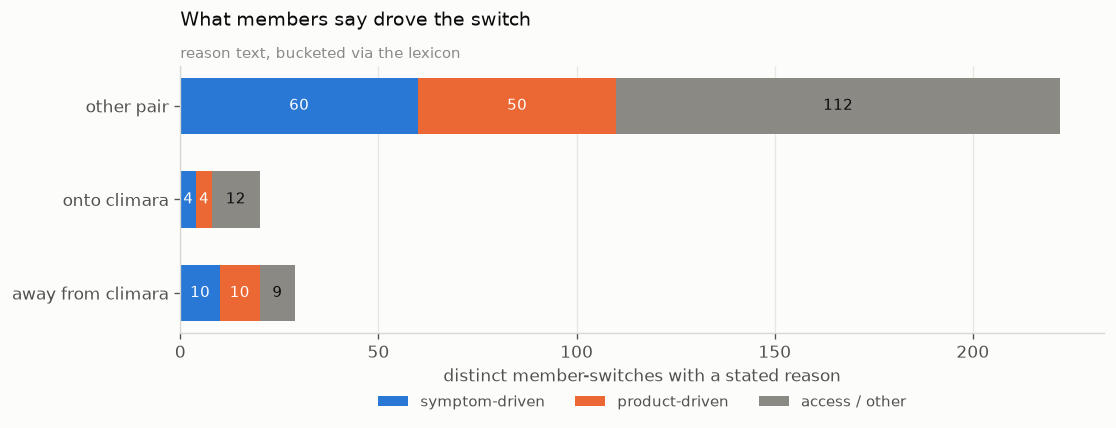

In [17]:
import re

sw = q("""SELECT author_id, doc_id, from_canonical, to_canonical, reason
            FROM switch_events WHERE reason IS NOT NULL""")

# The lexicon decides what is a symptom - no second vocabulary to maintain.
lex_sym = q("""SELECT DISTINCT canonical_id FROM mentions WHERE kind='symptom'""").canonical_id.dropna()
sym_alias = {}
for cid in lex_sym:
    sym_alias[cid] = cid.replace('_', ' ')

PRODUCT = re.compile(r'adhes|stick|peel|fall|lift|residue|applicator|device|patch size|messy|dry(ing)? time', re.I)
ACCESS  = re.compile(r'cost|price|insur|cover|pharmac|supply|script|afford|availab|doctor|gyn|gp|prescrib|convenien|prefer', re.I)

def bucket(reason):
    r = str(reason).lower()
    if PRODUCT.search(r):
        return 'product-driven'
    # symptom check: does any symptom entity name appear in the reason?
    for cid, name in sym_alias.items():
        if name in r or cid.split('_')[0] in r:
            return 'symptom-driven'
    if ACCESS.search(r):
        return 'access / other'
    return 'access / other'

sw['bucket'] = sw.reason.map(bucket)
sw['direction'] = np.where(sw.to_canonical == 'climara', 'onto climara',
                   np.where(sw.from_canonical == 'climara', 'away from climara', 'other pair'))

tab = (sw.drop_duplicates(['author_id','from_canonical','to_canonical','reason'])
         .groupby(['direction','bucket']).size().unstack(fill_value=0)
         .reindex(columns=['symptom-driven','product-driven','access / other'], fill_value=0))
print(tab.to_string()); print()

fig, ax = plt.subplots(figsize=(9.4, 3.8))
left = np.zeros(len(tab))
for col, colour in zip(tab.columns, [C1, C2, MUTED]):
    ax.barh(range(len(tab)), tab[col], left=left, color=colour, height=0.6, label=col)
    for i, (v, l) in enumerate(zip(tab[col], left)):
        if v: ax.annotate(str(v), (l + v/2, i), ha='center', va='center',
                          color='white' if colour != MUTED else INK, fontsize=9)
    left += tab[col].values
ax.set_yticks(range(len(tab))); ax.set_yticklabels(tab.index)
ax.set_xlabel('distinct member-switches with a stated reason')
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, labelcolor=INK2, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)
tidy(ax, 'What members say drove the switch', 'reason text, bucketed via the lexicon')
plt.tight_layout(); plt.show()

### Which symptoms accompany a switch

Not "do members with symptom X switch" — 90 of 100 members have a switch event and
nearly everyone reports every common symptom, so that rate is ~90% for every
symptom and says nothing. **Checked, and discarded.**

What does discriminate: the symptom **mix inside documents that describe a switch**,
against the mix everywhere else. Polarity, so diverging colour with a neutral
midpoint.

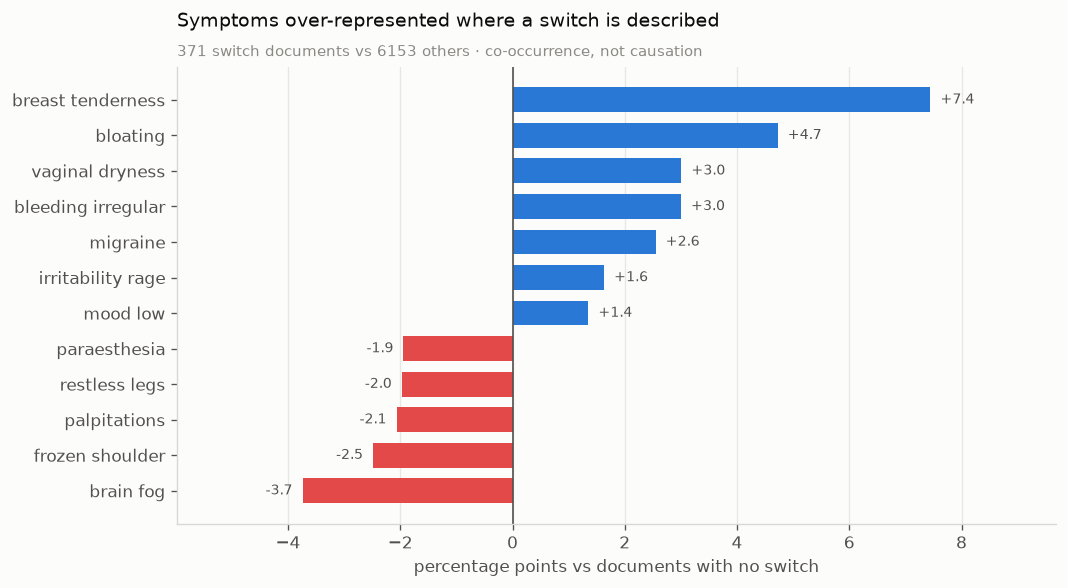

Reads as: treatment-attributable side effects (breast tenderness, bleeding,
bloating) cluster where switching is discussed; background menopause symptoms
(brain fog, frozen shoulder) do not. That is a correlation in the same
document, NOT evidence that the symptom caused the switch - the reason field
above is the only place a member states causation themselves.


In [18]:
switch_docs = set(q("SELECT DISTINCT doc_id FROM switch_events").doc_id)

inside  = sym[sym.doc_id.isin(switch_docs)].canonical_id.value_counts(normalize=True)
outside = sym[~sym.doc_id.isin(switch_docs)].canonical_id.value_counts(normalize=True)
diff = (inside - outside.reindex(inside.index).fillna(0)).sort_values()
show = pd.concat([diff.head(5), diff.tail(7)])

fig, ax = plt.subplots(figsize=(9, 5.0))
vals = show.values * 100
ax.barh(range(len(show)), vals,
        color=[DIV_POS if v > 0 else DIV_NEG for v in vals], height=0.7)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(range(len(show)))
ax.set_yticklabels([s.replace('_',' ') for s in show.index])
ax.set_xlabel('percentage points vs documents with no switch')
ax.grid(axis='y', visible=False); ax.margins(x=0.20)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.1f}', xy=(v, i), xytext=(6 if v>0 else -6, 0),
                textcoords='offset points', va='center',
                ha='left' if v>0 else 'right', color=INK2, fontsize=8.5)
tidy(ax, 'Symptoms over-represented where a switch is described',
     f'{len(switch_docs)} switch documents vs {sym.doc_id.nunique()-len(switch_docs)} others · '
     'co-occurrence, not causation')
plt.tight_layout(); plt.show()

print('Reads as: treatment-attributable side effects (breast tenderness, bleeding,')
print('bloating) cluster where switching is discussed; background menopause symptoms')
print('(brain fog, frozen shoulder) do not. That is a correlation in the same')
print('document, NOT evidence that the symptom caused the switch - the reason field')
print('above is the only place a member states causation themselves.')